# 02 Simple Neural Network

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build a feedforward neural network with PyTorch (the same ideas apply in Keras/TensorFlow)
- Train it on real data (MNIST digits) and see loss/accuracy
- Understand why we use a neural net instead of hand-coded rules for this task

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 4, lesson 04 "Multi-class Classification with Keras" — a feedforward network reading handwritten digits (the 8x8 set that ships with scikit-learn) with a softmax output; here the same design is rebuilt in PyTorch on full-size MNIST and taken apart.

**Used later in:** Course 09 (AIAT 123) — Unit 3, lesson 01 "DQN Implementation" — the network that replaces the Q-table.

---

## 🌍 Real life

**📌 Real case — the first neural network to do a real job.** LeCun and colleagues (*Neural Computation* 1(4), 541-551, 1989) trained a backpropagation network on real mail, not a toy set: the paper's abstract says the approach "has been successfully applied to the recognition of handwritten zip code digits provided by the U.S. Postal Service", and that "a single network learns the entire recognition operation, going from the normalized image of the character to the final classification". It is widely regarded as the earliest real-world deployment of a backprop-trained network, and it is the direct ancestor of the MNIST loop you are about to write: load images, forward pass, loss, backward pass, update.

**⚡ Why this matters — what goes wrong without it.** The alternative is writing the rules yourself: "a 7 has one horizontal stroke and one diagonal". Then someone writes a 7 with a crossbar, or a 1 with a serif, and your rule set grows another branch — forever. The network is never given a rule. It is given 5,000 examples and 109,386 weights, and the weights move until the loss falls: ours went **1.5278 → 0.5082** and accuracy **0.6284 → 0.8560** in two epochs. You wrote no rules at all.

**Where is this used?** Handwritten digit recognition is used in **postal sorting**, **form scanning**, **bank check reading**, and **captcha systems**.

**In this notebook we use** a **feedforward neural network** to **classify handwritten digits (0–9)**. We use it **instead of** hand-coded rules or simple ML (e.g. one rule per digit) **because** the network **learns features from data**; we don't have to design the features by hand.

---

**📌 Covers slide(s):** **01** — Anatomy of NN, TensorFlow, layers, fit(), loss; **23** — Keras Sequential, callbacks. *Do this notebook after those slides.*

**Before starting:** Run the imports cell below. If TensorFlow fails with a **charset_normalizer** or **md__mypyc** error, fix the environment: run in a terminal `pip install --upgrade charset-normalizer requests`, then restart the kernel. For other errors, see `DOCS/COLAB_SETUP.md`.


## Theory (short)

- A **neural network** = layers of neurons: input → hidden layer(s) → output.
- Each layer applies **weights** and an **activation function** (e.g. ReLU).
- **Training**: forward pass → compute **loss** (how wrong we are) → **backpropagation** (gradients) → **optimizer** updates weights.
- **Data flow:** input image → flatten → Dense(128) → ReLU → Dense(10) → Softmax → predicted class.
- We use a **feedforward NN** (not CNN yet) here to keep it simple; in the next unit we'll use CNNs for images to use spatial structure.

**The steps below put this theory into code.**


## 📥 Inputs & 📤 Outputs

**Inputs:** MNIST dataset (60k training + 10k test images, 28×28 grayscale digits), PyTorch (torchvision downloads MNIST), NumPy, Matplotlib.

**Dataset:** Real — MNIST (handwritten digits). Used so the example mimics real-world digit recognition.

**Outputs:** One figure with two plots (loss on every mini-batch update, and accuracy at each of the two epoch boundaries), a test accuracy number, 5 sample predictions printed as "true label → predicted label", and a confusion matrix over all 1,000 test images.

**Expected:** Loss should decrease and accuracy increase over epochs; test accuracy around 0.86 with this deliberately small setup (5k training images, 2 epochs); the full 60k set with ~10 epochs pushes past 0.97; most sample predictions should match the true labels. If loss stays flat, try more epochs or check learning rate.


In [1]:
# Step 1: Imports (run this first)
# Note: uses PyTorch (compatible with macOS) instead of TensorFlow/Keras
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
# Fix the seed so weight initialisation and batch shuffling repeat exactly:
# every run then prints the same accuracy the text below quotes.
torch.manual_seed(42)
print(f"PyTorch {torch.__version__}")
print("✅ Imports OK.")

PyTorch 2.13.0
✅ Imports OK.


In [2]:
# Step 2: Load MNIST — using a 5 000-sample subset so the notebook finishes quickly
# (Full MNIST has 60 000 samples; the concepts are identical with 5 000)
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
transform = transforms.ToTensor()  # normalises pixels to [0, 1]
full_train = datasets.MNIST('/tmp/mnist_data', train=True,  download=True, transform=transform)
full_test  = datasets.MNIST('/tmp/mnist_data', train=False, download=True, transform=transform)
# Subset for speed (5 000 train / 1 000 test)
import torch
train_data = torch.utils.data.Subset(full_train, range(5000))
test_data  = torch.utils.data.Subset(full_test,  range(1000))
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=128)
print('Training subset:', len(train_data), '| Test subset:', len(test_data))
print('Labels: 0–9 (digits)')

Training subset: 5000 | Test subset: 1000
Labels: 0–9 (digits)


In [3]:
# Step 3: ToTensor() already normalises to [0, 1]. Flatten happens inside model.
x_sample, y_sample = full_train[0]
print('Single image tensor shape:', x_sample.shape)  # (1, 28, 28)

Single image tensor shape: torch.Size([1, 28, 28])


In [4]:
# Step 4: Build model — feedforward NN (same structure as the Keras version)
# Input: 784 pixels → Dense(128, ReLU) → Dense(64, ReLU) → Dense(10, Softmax)
model = nn.Sequential(
    nn.Flatten(),          # 1×28×28  →  784
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10),     # raw logits; CrossEntropyLoss applies softmax internally
)
print(model)
print("Parameters:", sum(p.numel() for p in model.parameters()))

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=64, bias=True)
  (4): ReLU()
  (5): Linear(in_features=64, out_features=10, bias=True)
)
Parameters: 109386


In [5]:
# Step 5: Choose loss function and optimiser
criterion = nn.CrossEntropyLoss()          # equivalent to sparse_categorical_crossentropy
optimizer = optim.Adam(model.parameters()) # same default lr=1e-3

We use **2 epochs** here so the notebook runs in a few minutes; in real projects you'd use 10–50 (or more).


In [6]:
# Step 6: Train for 2 epochs (enough to see loss fall and accuracy rise)
# WHY: this manual loop is what Keras' fit() hides - forward pass, loss, backward pass, weight update.
# batch_loss keeps the loss of EVERY mini-batch update so the plot can show the real descent,
# not just two epoch averages.
history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': [], 'batch_loss': []}

# One epoch = one full pass over the training data.
for epoch in range(2):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    # For each mini-batch: clear old gradients, predict, measure error, backpropagate, update weights.
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward(); optimizer.step()
        history['batch_loss'].append(loss.item())   # one number per weight update
        total_loss    += loss.item() * len(yb)
        total_correct += (logits.argmax(1) == yb).sum().item()
        total         += len(yb)
    train_loss = total_loss / total
    train_acc  = total_correct / total

    # Validation pass: eval() and no_grad() switch off training behavior - we only measure here, never learn.
    model.eval()
    vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            logits = model(xb)
            vl += criterion(logits, yb).item() * len(yb)
            vc += (logits.argmax(1) == yb).sum().item()
            vt += len(yb)
    # Record per-epoch averages so we can plot learning curves later.
    history['loss'].append(train_loss);       history['val_loss'].append(vl/vt)
    history['accuracy'].append(train_acc);    history['val_accuracy'].append(vc/vt)
    print(f'Epoch {epoch+1}: loss={train_loss:.4f}  acc={train_acc:.4f}  '
          f'val_loss={vl/vt:.4f}  val_acc={vc/vt:.4f}')

Epoch 1: loss=1.5278  acc=0.6284  val_loss=0.7965  val_acc=0.7630


Epoch 2: loss=0.5082  acc=0.8560  val_loss=0.4680  val_acc=0.8650


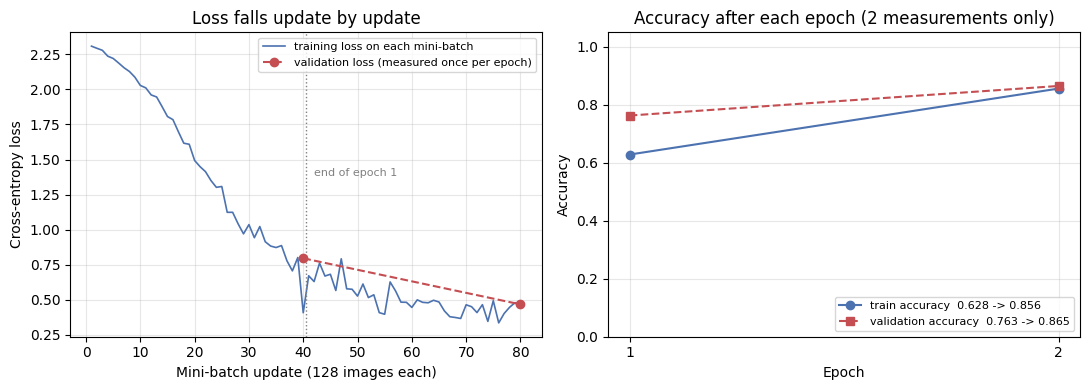

Mini-batch updates performed: 80   first loss 2.3078  last loss 0.4643


In [7]:
# Step 7: Plot the learning curves
# WHY: two epoch averages are only two points - a straight line between them says nothing about
#      what happened in between. The left panel plots every mini-batch update instead.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Left: one point per weight update (5000 images / batch 128 = 40 updates per epoch).
bl = history["batch_loss"]
per_epoch = len(bl) // 2
ax1.plot(range(1, len(bl) + 1), bl, color="#4c72b0", lw=1.2,
         label="training loss on each mini-batch")
ax1.axvline(per_epoch + 0.5, color="grey", ls=":", lw=1)
ax1.text(per_epoch + 2, max(bl) * 0.60, "end of epoch 1", fontsize=8, color="grey")
# Validation loss is measured once per epoch, so it gets two markers, not a line through the batches.
ax1.plot([per_epoch, 2 * per_epoch], history["val_loss"], "o--", color="#c44e52",
         label="validation loss (measured once per epoch)")
ax1.set_xlabel("Mini-batch update (128 images each)")
ax1.set_ylabel("Cross-entropy loss")
ax1.set_title("Loss falls update by update")
ax1.legend(fontsize=8, loc="upper right")
ax1.grid(alpha=0.3)

# Right: accuracy exists only at the two epoch boundaries - show it as measurements, not a trend.
ep = [1, 2]
# The values go in the legend, not next to the markers: at epoch 2 the two points nearly
# coincide, so floating labels there would be ambiguous.
a1, a2 = history["accuracy"]
v1, v2 = history["val_accuracy"]
ax2.plot(ep, history["accuracy"], "o-", color="#4c72b0",
         label=f"train accuracy  {a1:.3f} -> {a2:.3f}")
ax2.plot(ep, history["val_accuracy"], "s--", color="#c44e52",
         label=f"validation accuracy  {v1:.3f} -> {v2:.3f}")
ax2.set_xticks(ep)
ax2.set_ylim(0, 1.05)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy after each epoch (2 measurements only)")
ax2.legend(fontsize=8, loc="lower right")
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Mini-batch updates performed: {len(bl)}   first loss {bl[0]:.4f}  last loss {bl[-1]:.4f}")


**Read the figure.**

- **Left** — one point per weight update: 5,000 training images in batches of 128 gives 40 updates per epoch, 80 in total. The loss starts at **2.31** (which is ln 10, exactly what a network that is guessing uniformly scores) and ends at **0.46**. It falls *inside* an epoch, not only between epochs — that is what the two red validation markers alone could never show you. The curve is jagged because each point is a different mini-batch, some harder than others; the trend, not the wobble, is the learning.
- **Right** — accuracy exists only where we measured it: twice. The dashed segment between the two markers is drawn to guide the eye, not because we observed anything in between. Validation accuracy (0.763 → 0.865) sits **above** train accuracy (0.628 → 0.856) here: the train number is an average over the whole epoch including the terrible first batches, while validation is measured once at the end with the improved weights. That is normal this early and is *not* evidence against overfitting.

**What it proves:** the loop in Step 6 is working — the loss really is falling with every update. **What it does not prove:** that training is finished. Two epochs is where we stopped, not where the curve flattened.

In [8]:
# Step 8: Evaluate on test set + sample predictions
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        correct += (model(xb).argmax(1) == yb).sum().item()
        total   += len(yb)
print(f"Test accuracy: {correct/total:.4f}")

# Show 5 sample predictions
xs = torch.stack([test_data[i][0] for i in range(5)])
ys = [test_data[i][1] for i in range(5)]
with torch.no_grad():
    preds = model(xs).argmax(1).tolist()
print("Sample predictions (true → predicted):")
for i in range(5):
    print(f"  {ys[i]} → {preds[i]}")

Test accuracy: 0.8650
Sample predictions (true → predicted):
  7 → 7
  2 → 2
  1 → 1
  0 → 0
  4 → 4


## Step 9: The picture to show a reviewer

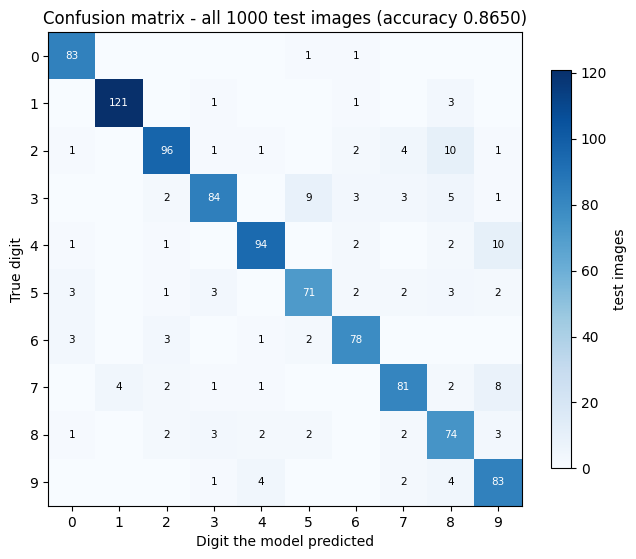

Wrong: 135 of 1000 test images (13.5%)
Three most frequent confusions:
  true 4 answered as 9: 10 times
  true 2 answered as 8: 10 times
  true 3 answered as 5: 9 times


In [9]:
# Step 9: Where do the remaining errors actually live?
# WHAT: a 10x10 confusion matrix over all 1,000 test images. Row = the true digit,
#       column = what the model answered. The diagonal is correct; everything else is a mistake.
# WHY: five hand-picked correct predictions prove nothing. This shows every error at once.
model.eval()
cm = np.zeros((10, 10), dtype=int)
with torch.no_grad():
    for xb, yb in test_loader:
        for t, p in zip(yb.tolist(), model(xb).argmax(1).tolist()):
            cm[t, p] += 1

fig, ax = plt.subplots(figsize=(6.6, 5.6))
im = ax.imshow(cm, cmap="Blues")
for t in range(10):
    for p in range(10):
        if cm[t, p]:
            ax.text(p, t, cm[t, p], ha="center", va="center", fontsize=7.5,
                    color="white" if cm[t, p] > cm.max() * 0.5 else "black")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("Digit the model predicted")
ax.set_ylabel("True digit")
ax.set_title(f"Confusion matrix - all {cm.sum()} test images (accuracy {np.trace(cm)/cm.sum():.4f})")
fig.colorbar(im, ax=ax, shrink=0.82, label="test images")
plt.tight_layout(); plt.show()

# Name the worst confusions in words so the picture can be checked against numbers.
off = cm - np.diag(np.diag(cm))
flat = np.argsort(-off, axis=None)[:3]
print(f"Wrong: {cm.sum() - np.trace(cm)} of {cm.sum()} test images "
      f"({100 * (1 - np.trace(cm)/cm.sum()):.1f}%)")
print("Three most frequent confusions:")
for k in flat:
    t, p = divmod(int(k), 10)
    print(f"  true {t} answered as {p}: {off[t, p]} times")


**Read the figure.**

The diagonal is correct answers; every off-diagonal cell is a mistake, and the row tells you which digit was betrayed. **135 of 1,000** test images are wrong (13.5%). The three heaviest confusions are **4 read as 9** (10 times), **2 read as 8** (10 times) and **3 read as 5** (9 times) — and every one of those pairs shares most of its ink, which is exactly the kind of error a model that sees pixels without geometry makes. Digit **1** is nearly perfect (121 of 126): it has the fewest ways to be written.

**Why this figure and not the five predictions above:** the five samples in Step 8 were all correct, and a reviewer cannot tell whether you picked them. This matrix has nowhere to hide — it contains every test image, right and wrong, in one picture. That is the answer to Discuss question 2.

## 💬 Discuss

1. Two "handwritten digit recognition" numbers appear in this notebook: **0.8650** (28×28 MNIST, 5,000 images, 2 epochs) and **96.9%** (8×8 sklearn digits). Both are real. Which one would you put in a report for a client, and what sentence must go next to it so the report is honest?
2. Our five sample predictions were all correct while 13.5% of the test set is wrong. What would you show a reviewer instead of five hand-picked examples, and why is that harder to fake?
3. A postal sorter can either guess a digit or refuse and send the parcel to a human. Which is worse for the postal service — a wrong digit or a refusal? What would you have to change about this model's output layer to make "refuse" possible at all?


## 🌍 Real-World Worked Example — Handwritten Digit Recognition

**Industry context:** The US Postal Service has been using digit recognition since the 1980s.  
ATMs, banks, and postal systems worldwide classify millions of handwritten digits daily.

Below we train a neural network on **real** digit images (same family as MNIST, 8×8 pixels, sklearn built-in — no download needed).

Test accuracy on real handwritten digits: 96.9%


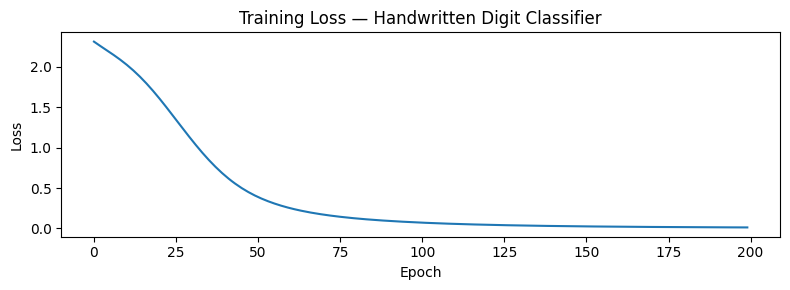

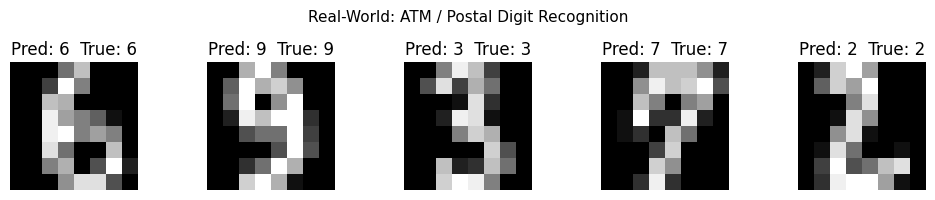

In [10]:
import torch, torch.nn as nn, torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np, matplotlib.pyplot as plt

# ── Real digit images (1797 samples, 8×8 pixels) ──────────────────────────
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target

# Split FIRST (the 8×8 images travel with their rows), then scale with
# statistics from the training set only (no test-set leakage).
X_tr, X_te, y_tr, y_te, img_tr, img_te = train_test_split(
    X, y, digits.images, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_tr)
X_tr = scaler.transform(X_tr).astype(np.float32)
X_te = scaler.transform(X_te).astype(np.float32)

X_tr_t = torch.tensor(X_tr)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
X_te_t = torch.tensor(X_te)
y_te_t = torch.tensor(y_te, dtype=torch.long)

# ── Two-layer neural network ───────────────────────────────────────
# Fix the seed so this demo prints the same accuracy every run (and the same number
# in notebooks 01, 02 and 03, which all run this identical example).
torch.manual_seed(0)
model = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 10)
)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.CrossEntropyLoss()
losses    = []

for epoch in range(200):
    model.train()
    pred = model(X_tr_t)
    loss = loss_fn(pred, y_tr_t)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())

# ── Evaluation ──────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    acc = (model(X_te_t).argmax(1) == y_te_t).float().mean().item()

print(f"Test accuracy on real handwritten digits: {acc*100:.1f}%")

# ── Plot training loss ──────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title("Training Loss — Handwritten Digit Classifier"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.tight_layout(); plt.show()

# ── Show sample predictions: test images paired with their own labels ─────
with torch.no_grad():
    sample_preds = model(X_te_t[:5]).argmax(1).tolist()

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(img_te[i], cmap='gray')   # the SAME test image the model predicted on
    ax.set_title(f"Pred: {sample_preds[i]}  True: {y_te[i]}")
    ax.axis('off')
plt.suptitle("Real-World: ATM / Postal Digit Recognition", fontsize=11)
plt.tight_layout(); plt.show()

**Read the two figures.**

- **Loss curve** — a 3-layer network on 1,437 real 8×8 digit images, full batch, 200 epochs. It starts at about **2.3**, which is ln 10: the loss of a model answering "all ten digits equally likely". By epoch 200 it is essentially 0. That is *training* loss, on images the model is free to memorise, so on its own it proves nothing.
- **Five test digits** — images from the 360 held-out samples the model never trained on, each with its prediction and true label. All five are right, and the honest number is next to them: **96.9%** on the whole held-out set.

**Careful with both.** A training-loss curve that reaches zero and five hand-picked correct predictions are the two most common ways a result gets oversold. The claim that survives review is the held-out accuracy — and better still, a confusion matrix over every test image (notebook 02, Step 9).

## ⚠️ Where this breaks

**Read our own number honestly: 0.8650 is not a deployable result.**

- **This architecture is the wrong shape for images.** A `Flatten` followed by `Linear` layers has no idea that pixel 15 and pixel 43 are vertical neighbours. Every stroke must be learned separately for every position it can appear in. Shift a digit three pixels and, to a Dense layer, it is a new pattern. Unit 2 replaces it with convolution for exactly this reason — and the same 8×8 digits at the end of this notebook reach **96.9%** partly because they are tiny and pre-centred, not because the model is better.
- **The gap to production is data and epochs, not cleverness.** We used 5,000 of MNIST's 60,000 images and 2 of the usual 10–50 epochs. Quoting 0.8650 as "what a neural network does on MNIST" would be dishonest; quoting it as "what 5,000 images and 2 epochs buy" is correct.
- **Five correct sample predictions are not evidence.** We printed five and all five matched. With 86.5% accuracy, the chance of five in a row being right is about 48% — you would see that result often by luck.
- **The assumption that must hold:** your test data comes from the same writers, scanners and preprocessing as your training data. MNIST guarantees this by construction. A real form-scanning deployment guarantees none of it.
- **Cheaper alternative:** for small, clean, pre-centred digits like the 8×8 sklearn set, an SVM or logistic regression reaches the high 90s in under a second with no epochs, no learning rate and no GPU.


---

## 🧩 Mini-exercise

**Try it (choose one):**
- Change the number of units in the first Dense layer (e.g. 128 → 64 or → 256), retrain for 2 epochs. What happens to loss and accuracy?
- Change `epochs` to 5 and run again. Does the model overfit (train accuracy much higher than test)?

*Add a new code cell below to try your change, then run. Then read the Summary.*

---

## ✅ Summary

**What you did:**
- Loaded MNIST (pixels normalized to [0, 1]; flattening happens inside the model).
- Built a feedforward NN (PyTorch `nn.Linear` layers) and trained it for 2 epochs.
- Plotted loss/accuracy and showed sample predictions.

**In real life you'd also:** use more epochs, save the model, and optionally use a CNN to keep image structure (see Unit 2).

**The main idea:** A neural network learns from data by updating weights using the loss and backpropagation; we don't hand-design the features.

**Next:** `05_backpropagation_detailed` shows how the gradients flow through the layers (how the network "learns").


## 📚 References

1. Rumelhart, D. E., Hinton, G. E. & Williams, R. J. (1986). *Learning representations by back-propagating errors*. Nature 323, 533-536. https://doi.org/10.1038/323533a0
2. Cybenko, G. (1989). *Approximation by Superpositions of a Sigmoidal Function*. Mathematics of Control, Signals and Systems 2, 303-314. https://doi.org/10.1007/BF02551274
3. Goodfellow, I., Bengio, Y. & Courville, A. (2016). *Deep Learning* (ch. 6). MIT Press. https://www.deeplearningbook.org/
4. Paszke, A. et al. (2019). *PyTorch: An Imperative Style, High-Performance Deep Learning Library*. NeurIPS. https://arxiv.org/abs/1912.01703

**Recent work (2024–2026)**

5. Liu, Z. et al. (2024). *KAN: Kolmogorov-Arnold Networks*. ICLR 2025. https://arxiv.org/abs/2404.19756 — a 2024 proposal that moves the learnable nonlinearity from the nodes onto the edges (splines instead of fixed activations). Read it as evidence that the plain MLP you just built is still an active research object, not settled furniture.
6. Ansel, J. et al. (2024). *PyTorch 2: Faster Machine Learning Through Dynamic Python Bytecode Transformation and Graph Compilation*. ASPLOS '24. https://doi.org/10.1145/3620665.3640366 — what the framework actually does with the layers you stacked: `torch.compile` rewrites Python bytecode into a graph and compiles it.
